# Self study 1

In this self study you should work on the code examples below together with the associated questions. The notebook illustrates a basic neural network implementation, where we implement most of the relevant functions from scratch, except for the calculation of the gradients, for which we rely on the functionality provided by <a urel="https://pytorch.org">PyTorch</a>. 

Since we rely on PyTorch functionality, we will also be using PyTorch's tensor data structure. This data structure operates in much the same way as numpy's ndarrays. You can find a brief introduction to PyTorch's tensors <a href="https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html">here</a>.  



The code illustrates the key concepts involved in the learning neural network. Go carefully through the code before starting to answer the questions at the end.

First we import the modules used in this selfstudy

In [3]:
import torch
from torchvision import datasets, transforms
from matplotlib import pyplot
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.functional as F
from torchvision import datasets, transforms
import torch.nn as nn

Through torch load the MNIST data set, which we will use in this self study. The MNIST database consists of grey scale images of handwritten digits. Each image is of size $28\times 28$; see figure below for an illustration. The data set is divided into a training set consisting of $60000$ images and a test set with $10000$ images; in both
data sets the images are labeled with the correct digits. If interested, you can find more information about the MNIST data set at http://yann.lecun.com/exdb/mnist/, including accuracy results for various machine learning methods.

![MNIST DATA](MNIST-dataset.png)

Using the data loader provided by torch we have an easy way of loading in data in batches (here of size 64). We can also make various other transformation of the data, such as normalization. The details for loading the data are not really that important, but if yiu are curious, you can find a quick introduction <a href="https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html">here</a>.

In [13]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=True, download=True,
                       transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize((0.1307,), (0.3081,))
                       ])),
        batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=False, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
        batch_size=batch_size, shuffle=True)

In the cell above, we are loading data in batches, which is subsequently used during optimization. We didn't discuss batch based learning during the last lecture, but please take a look at Slides 24 and 25 to get the gist of the approach. We will cover it in more detail during the next lecture.   

Each batch is a list of two elements. The first element encodes the digit and has dimensions [64,1,28,28] (the figures are greyscale with no rbg channel, hence the '1'), and the second element contains the class/label information. 

Batch dimension (digit): torch.Size([128, 1, 28, 28])
Batch dimension (target): torch.Size([128])
Target: 0 with shape torch.Size([])


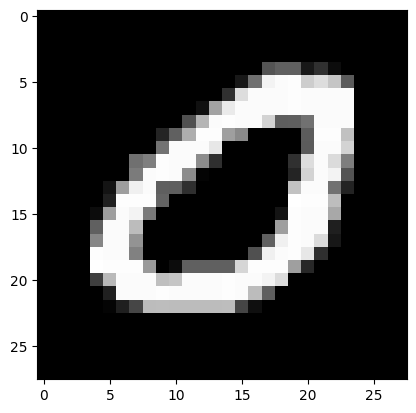

In [14]:
batch = next(iter(train_loader))
print(f"Batch dimension (digit): {batch[0].shape}")
print(f"Batch dimension (target): {batch[1].shape}")
digit_batch = batch[0]
img = digit_batch[0,:]
pyplot.imshow(img.reshape((28, 28)), cmap="gray")
print(f"Target: {batch[1][0]} with shape {batch[1][0].shape}")

With PyTorch we can specify that the tensors require gradients. This will make PyTorch record all operations performed on the tensors, so that we can afterwards calculate the gradients automatically using back propagation. See also the code example from the last lecture.

For the first part of this self study we will specify a neural network, which will encode a softmax function (see, e.g., Page 180 in <a href="https://www.deeplearningbook.org/contents/mlp.html">The Deep Learning book</a>). For this we need a (randomly initialized) weight matrix and a bias, and for both of them we need their gradients wrt. our error function (yet to be defined) in order to perform learning. Note that to facilitate matrix multiplication we will flatten our image from $28\times 28$ to $784$. 

In [15]:
weights = torch.randn(784, 10) / np.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

Out model specification

In [16]:
def softmax(x):
    return x.exp() / x.exp().sum(-1).unsqueeze(-1)

def model(xb):
    return softmax(xb @ weights + bias)

Let's test our model (with our randomly initialized weights)

In [17]:
# We flatten the digit representation so that it is consistent with the weight matrix
xb = digit_batch.flatten(start_dim=1)
print(f"Batch shape: {xb.shape}")
preds = model(xb)
print(f"Prediction on first image {preds[0]}")
print(f"Corresponding classification: {preds[0].argmax()}")

Batch shape: torch.Size([128, 784])
Prediction on first image tensor([0.0799, 0.0425, 0.0085, 0.0293, 0.1355, 0.2486, 0.1001, 0.0690, 0.2691,
        0.0175], grad_fn=<SelectBackward0>)
Corresponding classification: 8


Next we define our loss function, in this case the log-loss (or negative log-likelihood):

In [18]:
def nll(input, target):
    return (-input[range(target.shape[0]), target].log()).mean() 
loss_func = nll

# Make a test calculation
yb = batch[1]
print(loss_func(preds,yb))

tensor(2.7963, grad_fn=<MeanBackward0>)


In the end, we are interested in the accuracy of our model

In [19]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [20]:
print(f"Accuracy of model on batch (with random weights): {accuracy(preds, yb)}")

Accuracy of model on batch (with random weights): 0.0546875


Now we are ready to combine it all and perform learning

In [21]:
# epochs = 1  # how many epochs to train for
# lr = 0.0001  # learning rate

# train_losses = []
# for epoch in range(epochs):

#     for batch_idx, (xb, yb) in enumerate(train_loader):

#         xb = xb.squeeze().flatten(start_dim=1)
#         pred = model(xb)
#         # We specify the loss
#         loss = loss_func(pred, yb)
#         # and perform backpropagation    
#         loss.backward()
#         # Lastly we update the weights and bias (torch.no_grad() ensures that no gradient 
#         # calculations are taking place in this part of the code)
#         with torch.no_grad():
#             weights -= weights.grad * lr
#             bias -= bias.grad * lr

#             # After updating we set the **gradients** to zero so that we ar eready for the next round
#             weights.grad.zero_()
#             bias.grad.zero_()

#             if batch_idx % 50 == 0:
#                 with torch.no_grad():
#                     train_loss = np.mean([loss_func(model(txb.squeeze().flatten(start_dim=1)), tyb).item() for txb, tyb in train_loader])
#                     print(f"Epoch: {epoch}, B-idx: {batch_idx}, Training loss: {train_loss}")
#                     train_losses.append(train_loss)

Plot the evolution of the training loss

In [22]:
# plt.plot(range(len(train_losses)), train_losses)

## Exercises 
1. Experiment with different variations of the gradient descent implementation; try varying the learning rate and the batch size. Assuming that you have a fixed time budget (say 2 minutes for learning), what can we then say about the effect of changing the parameters?
2. Implement momentum in the learning algorithm. How does it affect the results?
3. Try with different initialization schemes for the parameters (e.g. allowing for larger values). How does it affect the behavior of the algorithm?
4. Analyze the behavior of the algorithm on the test set and implement a method for evaluating the accuracy over the entire training/test set.
5. If you feel adventorous, you are welcome to try to specify and experiment with other more advanced model architectures (cell 23). 

### Responses

1. Changing parameters like lr and the batch can change the speed of the training. E.g. with l=0.1 and batch 50 it takes 7m36s seconds to do 2 epoch with a the loss reaching 2.96. While with lr=0.0001 and a batch of 128 for 2 epoch we get a running time of 3m38s and a min loss value of 1.77. This results show the importance of finding the right balance between the batch size and how a small learning rate can help with finding a better result. 

2. The implemetation of momentum significantly improves the convergence of the loss that decreases at much more steady pace.

3. -

In [32]:
epochs = 4  # how many epochs to train for
lr = 0.001  # learning rate
alpha = 0.9 # momentum rate

#initialize velocity tensors here
velocity_weights = torch.zeros_like(weights)
velocity_bias = torch.zeros_like(bias)

train_losses = []
for epoch in range(epochs):

    for batch_idx, (xb, yb) in enumerate(train_loader):

        xb = xb.squeeze().flatten(start_dim=1)
        pred = model(xb)
        # We specify the loss
        loss = loss_func(pred, yb)
        # and perform backpropagation    
        loss.backward()
        # Lastly we update the weights and bias (torch.no_grad() ensures that no gradient 
        # calculations are taking place in this part of the code)
        with torch.no_grad():
            velocity_weights = alpha * velocity_weights + weights.grad
            weights -= velocity_weights * lr

            velocity_bias = alpha * velocity_bias + bias.grad
            bias -= velocity_bias * lr

            # After updating we set the **gradients** to zero so that we ar eready for the next round
            weights.grad.zero_()
            bias.grad.zero_()

            if batch_idx % 50 == 0:
                with torch.no_grad():
                    train_loss = np.mean([loss_func(model(txb.squeeze().flatten(start_dim=1)), tyb).item() for txb, tyb in train_loader])
                    print(f"Epoch: {epoch}, B-idx: {batch_idx}, Training loss: {train_loss}")
                    train_losses.append(train_loss)

Epoch: 0, B-idx: 0, Training loss: 0.5019088165719372
Epoch: 0, B-idx: 50, Training loss: 0.4734968869670876
Epoch: 0, B-idx: 100, Training loss: 0.449465074455306
Epoch: 0, B-idx: 150, Training loss: 0.4309987590384127
Epoch: 0, B-idx: 200, Training loss: 0.416262656513816
Epoch: 0, B-idx: 250, Training loss: 0.40785519044790697
Epoch: 0, B-idx: 300, Training loss: 0.39602083701695967
Epoch: 0, B-idx: 350, Training loss: 0.38772703529293856
Epoch: 0, B-idx: 400, Training loss: 0.38190850596438086
Epoch: 0, B-idx: 450, Training loss: 0.3757518769136624
Epoch: 1, B-idx: 0, Training loss: 0.37373110928388037
Epoch: 1, B-idx: 50, Training loss: 0.36842539102665145
Epoch: 1, B-idx: 100, Training loss: 0.3636560401619116
Epoch: 1, B-idx: 150, Training loss: 0.35956365982098365
Epoch: 1, B-idx: 200, Training loss: 0.355994775414721
Epoch: 1, B-idx: 250, Training loss: 0.35271082783558727
Epoch: 1, B-idx: 300, Training loss: 0.34987057799469434
Epoch: 1, B-idx: 350, Training loss: 0.346644646

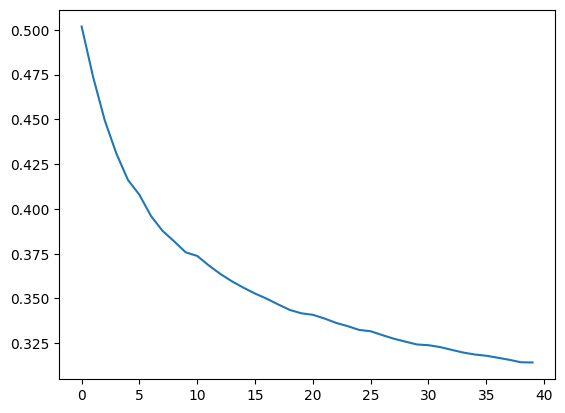

In [34]:
plt.plot(range(len(train_losses)), train_losses)

4. 

In [35]:
def evaluate_full_dataset(model, train_loader, test_loader, loss_fn):
    """
    Evaluate model accuracy and loss on entire training, validation, and test sets
    """
    # model.eval()
    
    results = {}
    
    # Evaluate on training set
    train_loss = 0
    train_correct = 0
    with torch.no_grad():
    # Disables gradient calculation - we're only doing inference, not training
    # This saves memory and speeds up computation
    
        for data, target in train_loader:
            # Loop through all batches in the training set
            
            data = data.flatten(start_dim=1)
            # Flatten images from [batch_size, 1, 28, 28] to [batch_size, 784]
            # This prepares data for your linear model
            
            output = model(data)
            # Get model predictions (softmax probabilities for each class)
            # output shape: [batch_size, 10] (10 digits: 0-9)
            
            train_loss += loss_fn(output, target).item() * data.size(0)
            # Calculate loss for this batch
            # .item() converts tensor to Python number
            # Multiply by batch_size to accumulate total loss (not averaged)
            
            pred = output.argmax(dim=1, keepdim=True)
            # Get predicted class (0-9) with highest probability
            # argmax(dim=1) finds max across the 10 classes
            # shape: [batch_size, 1]
            
            train_correct += pred.eq(target.view_as(pred)).sum().item()
            # Compare predictions with true labels
            # .eq() checks equality (returns True/False for each sample)
            # .sum() counts how many predictions were correct
            # .item() converts to Python number and add to running total
    
    train_loss /= len(train_loader.dataset)
    train_accuracy = train_correct / len(train_loader.dataset)
    results['train'] = {'loss': train_loss, 'accuracy': train_accuracy}
    
    # Evaluate on test set
    test_loss = 0
    test_correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data = data.flatten(start_dim=1)
            output = model(data)
            test_loss += loss_fn(output, target).item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            test_correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_accuracy = test_correct / len(test_loader.dataset)
    results['test'] = {'loss': test_loss, 'accuracy': test_accuracy}
    
    # Print results
    print("\n" + "="*60)
    print("FULL DATASET EVALUATION")
    print("="*60)
    print(f"Training   - Loss: {results['train']['loss']:.4f}, Accuracy: {results['train']['accuracy']:.4f} ({train_correct}/{len(train_loader.dataset)})")
    print(f"Test       - Loss: {results['test']['loss']:.4f}, Accuracy: {results['test']['accuracy']:.4f} ({test_correct}/{len(test_loader.dataset)})")
    print("="*60 + "\n")
    
    return results

# Call this after training is complete
final_reult = evaluate_full_dataset(model, train_loader, test_loader, loss_func)


FULL DATASET EVALUATION
Training   - Loss: 0.3140, Accuracy: 0.9108 (54650/60000)
Test       - Loss: 0.3044, Accuracy: 0.9126 (9126/10000)



# Addendum

In the exercise and code above, we only took modest advantage of the functionality PyTorch has to offer when it comes to specifying and training neural networks. Below I have therefore tried to illustrated another approach for modeling the MNIST data, but now using a concolutional neural network. You can find a brief but well-written intorduction to convolutional neural networks here:

* http://colah.github.io/posts/2014-07-Conv-Nets-Modular/

In particular, we will work with the _torch.nn_ module provided by PyTorch. A short introduction to this module and how to define neural networks in PyTorch can be found at

* https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html#sphx-glr-beginner-blitz-neural-networks-tutorial-py

* https://pytorch.org/tutorials/beginner/nn_tutorial.html

You may either go through these tutorials before move on or consult them when needed as you move forward in the notebook. The former tutorial is part of a general tutorial package to PyTorch, which can be found at (this also includes a nice introduction to tensors in PyTorch)

* https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

Here we will be a bit more careful with our data. Specifically, we will divide the data into a training, validation, and test, and use the training and validation set for model learning (in the previous self study we did not have a validation set). 

The data set is created by setting aside a randomly chosen subset of the data, where the splitting point is found using the help function *split_indicies* below.

In [4]:
def split_indicies(n, val_pct):
    # Size of validation set
    n_val = int(n*val_pct)
    # Random permutation
    idxs = np.random.permutation(n)
    # Return first indexes for the validation set
    return idxs[n_val:], idxs[:n_val]

# Load the data
train_dataset = datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ]))

# Get the indicies for the training data and test data (the validation set will consists of 20% of the data)
train_idxs, val_idxs = split_indicies(len(train_dataset), 0.2)

# Define samplers (used by Dataloader) to the two sets of indicies
train_sampler = SubsetRandomSampler(train_idxs)
val_sampler = SubsetRandomSampler(val_idxs)

# Specify data loaders for our training and test set (same functionality as in the previous self study)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, sampler=val_sampler)

print(f"Number of training examples: {len(train_idxs)}")
print(f"Number of validation examples: {len(val_idxs)}")

Number of training examples: 48000
Number of validation examples: 12000


The test set is loaden is the usual fashion.

In [5]:
test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=False, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
        batch_size=64, shuffle=True)

## Specifying the model

When using the _torch.nn_ for specifying our model we subclass the _nn.Module_. The model thus holds all the parameters of the model (see the _init_ function) as well as a specification of the forward step. We don't have to keep track of the backward pass, as PyTorch handles this for us.

In [6]:
class MNIST_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Define a convolution operator with 1 input channel, 15 output channels and a kernel size of 5x5
        self.conv1 = nn.Conv2d(1, 15, 5)
        # Since we are not doing padding (see Lecture 2, Slide 38) the width of the following layer is reduced; for
        # each channel the resulting dimension is 24x24. We feed the resulting representation through a linear 
        # layer, giving 10 values as output - one for each digit.
        self.fc = nn.Linear(15 * 24 * 24, 10)
        self.out = None

    def forward(self, xb):

        # Reshape the input tensor; '-1' indicates that PyTorch will fill-in this 
        # dimension, whereas the '1' indicates that we only have one color channel. 
        xb = xb.view(-1, 1, 28, 28)
        # Apply convolution and pass the result through a ReLU function
        xb = F.relu(self.conv1(xb))
        # Reshape the representation
        xb = xb.view(-1, 15*24*24)
        # Apply the linear layer
        xb = self.fc(xb)
        # and set the result as the output. Note that we don't take a softmax as this is handled internally in the 
        # loss function defined below.
        self.out = xb

        return xb

## Learning and evaluating the model

For learning the model, we will use the following function which performs one iteration over the training data. The function also takes an _epoch_ argument, but this is only used for reporting on the learning progress

In [7]:
def train(model, train_loader, loss_fn, epoch):
    # Tell PyTorch that this function is part of the training
    model.train()

    # As optimizer we use stochastic gradient descent as defined by PyTorch. PyTorch also includes a variety 
    # of other optimizers 
    learning_rate = 0.01
    opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # Iterate over the training set, one batch at the time, as in the previous self sudy
    for batch_idx, (data, target) in enumerate(train_loader):
        # Get the prediction
        y_pred = model(data)
        
        # Remember to zero the gradients so that they don't accumulate
        opt.zero_grad()

        # Calculate the loss and and the gradients  
        loss = loss_fn(y_pred, target)
        loss.backward()

        # Optimize the parameters by taking one 'step' with the optimizer
        opt.step()

        # For every 10th batch we output a bit of info
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.sampler),
                       100. * batch_idx * len(data) / len(train_loader.sampler), loss.item()))

In the end, we also want to validate our model. To do this we define the function below, which takes a data_loader (either the validation or test set) and reports the model's accuracy and loss on that data set.

In [8]:
def test_model(_model, data_loader, loss_fn):
    # Tell PyTorch that we are performing evaluation
    _model.eval()
    
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in data_loader:
            output = _model(data)
            test_loss += loss_fn(output, target).item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(data_loader.dataset)

    print('\nTest/validation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(data_loader.sampler),
        100. * correct / len(data_loader.sampler)))

## A couple of helper functions

Learning a deep neural network can be time consuming, and it might therefore be nice to be able to save and load previously learned models (see also https://pytorch.org/tutorials/beginner/saving_loading_models.html).

In [9]:
def save_model(file_name, model):
    torch.save(model, file_name)

def load_model(file_name):
    model = torch.load(file_name)
    model.eval()
    return model

## Wrapping things up

Finally, we will do the actual learning of the model.

In [10]:
# The number of passes that will be made over the training set
num_epochs = 2
# torch.nn defines several useful loss-functions, which we will take advantage of here (see Lecture 1, Slide 11, Log-loss).
loss_fn = nn.CrossEntropyLoss()

In [11]:
# Instantiate the model class
model = MNIST_CNN()
# and get some information about the structure
print('Model structure:')
print(model)

Model structure:
MNIST_CNN(
  (conv1): Conv2d(1, 15, kernel_size=(5, 5), stride=(1, 1))
  (fc): Linear(in_features=8640, out_features=10, bias=True)
)


### Iterate over the data set

We iterate over the data set for *num_epochs* number of iterations. At each iteration we also calculate the loss/accuracy on the validation set.

In [12]:
for i in range(num_epochs):
    train(model, train_loader, loss_fn, i)
    # Evaluate the model on the test set
    test_model(model, val_loader, loss_fn)

Train Epoch: 0 [0/48000 (0%)]	Loss: 2.303196
Train Epoch: 0 [640/48000 (1%)]	Loss: 0.962250
Train Epoch: 0 [1280/48000 (3%)]	Loss: 0.736290
Train Epoch: 0 [1920/48000 (4%)]	Loss: 0.451593
Train Epoch: 0 [2560/48000 (5%)]	Loss: 0.647182
Train Epoch: 0 [3200/48000 (7%)]	Loss: 0.726094
Train Epoch: 0 [3840/48000 (8%)]	Loss: 0.379308
Train Epoch: 0 [4480/48000 (9%)]	Loss: 0.449474
Train Epoch: 0 [5120/48000 (11%)]	Loss: 0.489350
Train Epoch: 0 [5760/48000 (12%)]	Loss: 0.447043
Train Epoch: 0 [6400/48000 (13%)]	Loss: 0.414135
Train Epoch: 0 [7040/48000 (15%)]	Loss: 0.359508
Train Epoch: 0 [7680/48000 (16%)]	Loss: 0.334018
Train Epoch: 0 [8320/48000 (17%)]	Loss: 0.469812
Train Epoch: 0 [8960/48000 (19%)]	Loss: 0.558694
Train Epoch: 0 [9600/48000 (20%)]	Loss: 0.378308
Train Epoch: 0 [10240/48000 (21%)]	Loss: 0.382114
Train Epoch: 0 [10880/48000 (23%)]	Loss: 0.274569
Train Epoch: 0 [11520/48000 (24%)]	Loss: 0.402087
Train Epoch: 0 [12160/48000 (25%)]	Loss: 0.172590
Train Epoch: 0 [12800/48000 

After learning we evaluate the model on the _test set_ and save the resulting structure.

In [13]:
# Evaluate the model on the test set
test_model(model, test_loader, loss_fn)
# Save the model
save_model('conv.pt', model)


Test/validation set: Average loss: 0.0021, Accuracy: 9648/10000 (96%)



In [14]:
print(model)

MNIST_CNN(
  (conv1): Conv2d(1, 15, kernel_size=(5, 5), stride=(1, 1))
  (fc): Linear(in_features=8640, out_features=10, bias=True)
)


## Supplmentary exercises

1. Familiarize yourself with the code above and consult the PyTorch documentation when needed.
2. Experiment with different NN architectures (also varying the convolutional parameters: size, stride, padding, etc) and observe the effect wrt. the loss/accuracy on the training and validation dataset (training, validation). Consult the reference PyTorch documentation as needed. **IMPORTANT:** ignore the test set at this stage (i.e., comment out the relevant lines above) so that the results for the test set do not influence your model choice.
3. In the model above we use a simple gradient descent learning scheme. Try other types of optimizers (see https://pytorch.org/docs/stable/optim.html) and analyze the effect.
4. If you feel adventurous, try investigating some of the other datasets that come prepacakged with PyTorch (see https://pytorch.org/vision/0.8/datasets.html). For instnce, for FashionMNIST you only need to change the dataloader from datasets.MNIST to datasets.FashionMNIST.